In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
from scipy.ndimage import rotate
import numpy as np

# -----------------------------
# Parameters
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_images = 4         # number of slices per sample
crop = 256
image_size = 256
batch_size = 4
epochs = 50

lr_G = 2e-4
lr_D = 1e-4
beta1 = 0.5
lambda_L1 = 100.0

In [2]:
# -----------------------------
# Forward Projection
# -----------------------------
angles = np.linspace(0, 180, image_size, endpoint=False)

def compute_sinogram(img_tensor):
    img = img_tensor[0].numpy()
    sino = []
    for theta in angles:
        rotated = rotate(img, theta, reshape=False, order=1)
        projection = np.sum(rotated, axis=0)
        sino.append(projection)
    return torch.tensor(np.array(sino)).unsqueeze(0)  # (1, H, W)

In [3]:
# -----------------------------
# Transform
# -----------------------------
transform = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((image_size, image_size)),
    transforms.CenterCrop(crop),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [4]:
# -----------------------------
# Load PET dataset
# -----------------------------
pet_base_ds = ImageFolder("D:/New folder/DatasetX/", transform=transform)

In [ ]:
# -----------------------------
# Precompute sinograms
# -----------------------------
precomputed_sinos = []
for i in range(len(pet_base_ds)):
    img, _ = pet_base_ds[i]
    sino = compute_sinogram(img)
    precomputed_sinos.append(sino)
precomputed_sinos = torch.stack(precomputed_sinos)  # (N, 1, H, W)

In [ ]:
def center_crop_tensor(x, crop_size):
    """
    x: tensor (..., H, W)
    crop_size: int
    """
    _, H, W = x.shape
    top = (H - crop_size) // 2
    left = (W - crop_size) // 2
    return x[:, top:top + crop_size, left:left + crop_size]
# -----------------------------
# Multi-Slice Dataset
# -----------------------------
class MultiSliceDataset(Dataset):
    def __init__(self, pet_dataset, sinos_tensor, num_slices, crop_size=180):
        self.pet_ds = pet_dataset
        self.sinos = sinos_tensor
        self.num_slices = num_slices
        self.crop_size = crop_size

    def __len__(self):
        return len(self.pet_ds) - self.num_slices + 1

    def __getitem__(self, idx):
        # ---------------------
        # PET slices (already transformed)
        # ---------------------
        pet_slices = [self.pet_ds[idx + i][0] for i in range(self.num_slices)]
        pet_stack = torch.cat(pet_slices, dim=0)  # (num_slices, H, W)

        # ---------------------
        # Sinogram slices (crop here)
        # ---------------------
        sino_slices = []
        for i in range(self.num_slices):
            sino = self.sinos[idx + i]          # (1, 256, 256)
            sino = center_crop_tensor(sino, self.crop_size)  # (1, 180, 180)
            sino_slices.append(sino)

        sino_stack = torch.cat(sino_slices, dim=0)  # (num_slices, 180, 180)

        return pet_stack, sino_stack

dataset = MultiSliceDataset(
    pet_base_ds,
    precomputed_sinos,
    num_images,
    crop_size=crop
)

train_dl = DataLoader(dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# -----------------------------
# Generator
# -----------------------------
class PETGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(num_images, 64, 4, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.Conv2d(64, 128, 4, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.Conv2d(128, 256, 4, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            nn.ConvTranspose2d(256, 128, 4, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, num_images, 4, 1, 1),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
# -----------------------------
# Discriminator
# -----------------------------
class PETDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(num_images * 2, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 1, 4, 1, 0)
        )

    def forward(self, sino, pet):
        x = torch.cat([sino, pet], dim=1)
        return self.model(x)

In [ ]:
# -----------------------------
# Initialize models and optimizers
# -----------------------------
G = PETGenerator().to(device)
D = PETDiscriminator().to(device)

adversarial_loss = nn.BCEWithLogitsLoss()

optimizer_G = optim.Adam(G.parameters(), lr=lr_G, betas=(beta1, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=lr_D, betas=(beta1, 0.999))

[Epoch 1/50] D_loss: 0.6228 | G_loss: 5.5078


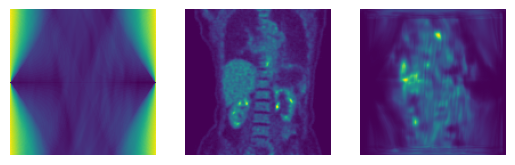

[Epoch 2/50] D_loss: 0.5782 | G_loss: 5.3658


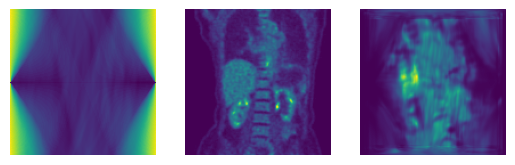

[Epoch 3/50] D_loss: 0.5146 | G_loss: 5.5560


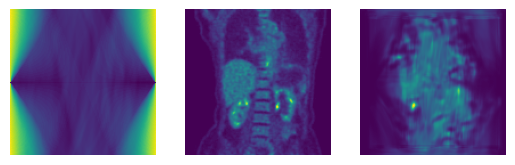

[Epoch 4/50] D_loss: 0.4932 | G_loss: 5.5388


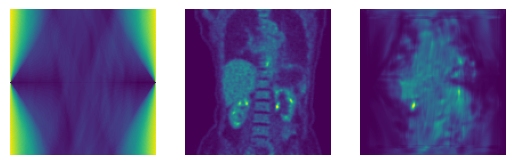

[Epoch 5/50] D_loss: 0.4978 | G_loss: 5.5094


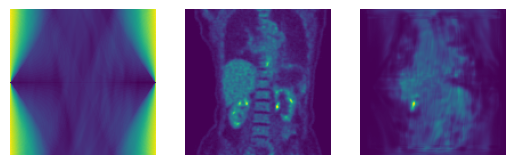

[Epoch 6/50] D_loss: 0.4954 | G_loss: 5.4048


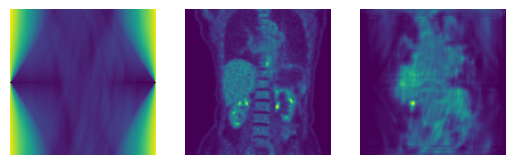

[Epoch 7/50] D_loss: 0.5012 | G_loss: 5.2642


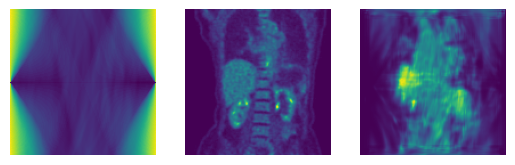

[Epoch 8/50] D_loss: 0.5170 | G_loss: 5.2238


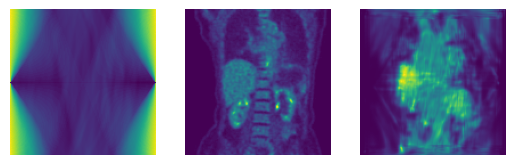

[Epoch 9/50] D_loss: 0.5514 | G_loss: 5.0917


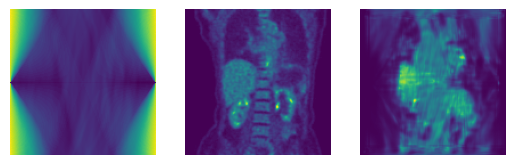

[Epoch 10/50] D_loss: 0.5403 | G_loss: 5.1835


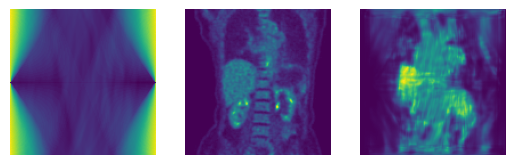

[Epoch 11/50] D_loss: 0.5214 | G_loss: 5.3597


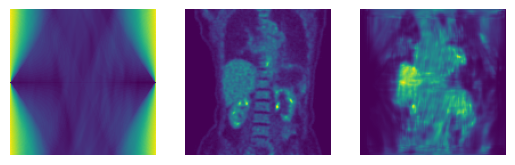

[Epoch 12/50] D_loss: 0.5119 | G_loss: 5.3498


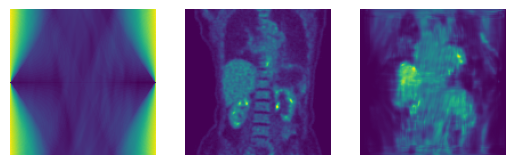

[Epoch 13/50] D_loss: 0.5152 | G_loss: 5.3323


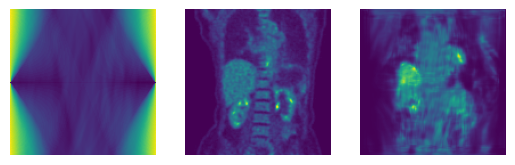

[Epoch 14/50] D_loss: 0.4678 | G_loss: 5.4445


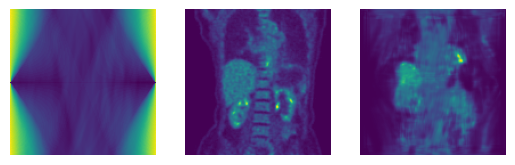

[Epoch 15/50] D_loss: 0.4715 | G_loss: 5.4149


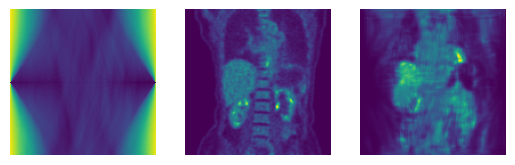

[Epoch 16/50] D_loss: 0.4672 | G_loss: 5.4573


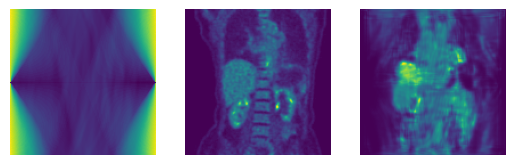

[Epoch 17/50] D_loss: 0.4793 | G_loss: 5.3601


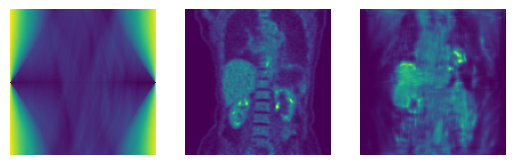

[Epoch 18/50] D_loss: 0.4684 | G_loss: 5.4493


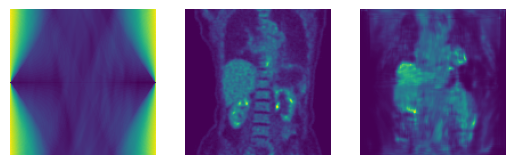

[Epoch 19/50] D_loss: 0.4632 | G_loss: 5.3418


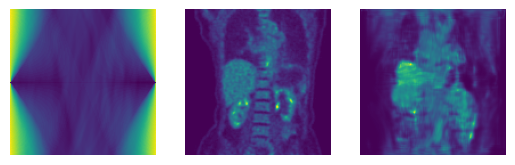

[Epoch 20/50] D_loss: 0.4893 | G_loss: 5.4363


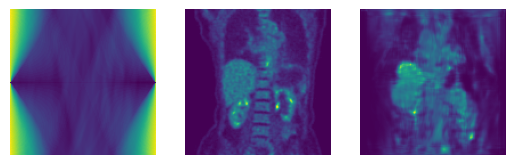

[Epoch 21/50] D_loss: 0.4630 | G_loss: 5.3062


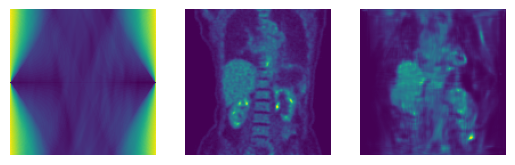

KeyboardInterrupt: 

In [ ]:
# -----------------------------
# Training loop
# -----------------------------
import matplotlib.pyplot as plt
for epoch in range(epochs):
    for pet_real, sino_real in train_dl:
        pet_real = pet_real.to(device)
        sino_real = sino_real.to(device)

        # ---------------------
        # Train Discriminator
        # ---------------------
        optimizer_D.zero_grad()
        pet_fake = G(sino_real)

        pred_real = D(sino_real, pet_real)
        pred_fake = D(sino_real, pet_fake.detach())

        valid = torch.full_like(pred_real, 0.9)
        fake  = torch.full_like(pred_fake, 0.1)

        d_loss = (adversarial_loss(pred_real, valid) + adversarial_loss(pred_fake, fake)) / 2
        d_loss.backward()
        optimizer_D.step()

        # ---------------------
        # Train Generator
        # ---------------------
        optimizer_G.zero_grad()
        adv_loss = adversarial_loss(D(sino_real, pet_fake), torch.ones_like(pred_fake))
        l1_loss = F.l1_loss(pet_fake, pet_real)
        g_loss = adv_loss + lambda_L1 * l1_loss
        g_loss.backward()
        optimizer_G.step()
        

    print(f"[Epoch {epoch+1}/{epochs}] D_loss: {d_loss.item():.4f} | G_loss: {g_loss.item():.4f}")
    fig, (ax1, ax2,ax3) = plt.subplots(1, 3)
    ax1.set_axis_off()
    ax2.set_axis_off()
    ax3.set_axis_off()
    ax1.imshow(sino_real.cpu().detach().numpy()[0][0].reshape(256,256))
    ax2.imshow(pet_real.cpu().detach().numpy()[0][0].reshape(256,256))
    ax3.imshow(pet_fake.cpu().detach().numpy()[0][0].reshape(256,256))
    plt.show()

print("Training complete!")

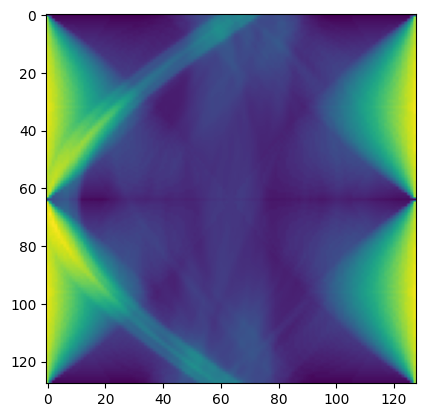

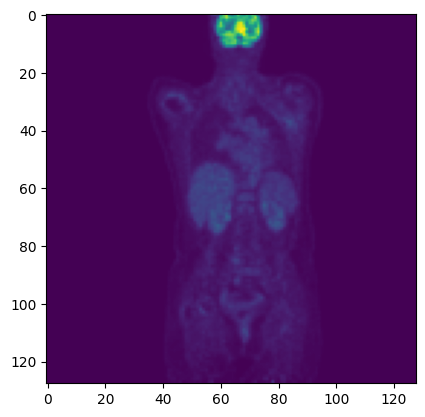

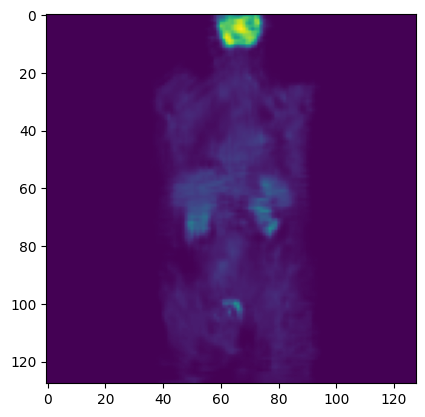

In [ ]:

#sino_real = sino_real.to(device)

#pet_real = pet_real.view(batch_size, num_images, 1, crop, crop)
#sino_real = sino_real.view(batch_size, num_images, 1, crop, crop)

# -----------------------------
# Train Discriminator
# -----------------------------
optimizer_D.zero_grad()

pet_fake = G(sino_real)
import matplotlib.pyplot as plt
plt.imshow(sino_real.cpu().detach().numpy()[0][0].reshape(256,256))
plt.show()
plt.imshow(pet_real.cpu().detach().numpy()[0][0].reshape(256,256))
plt.show()
plt.imshow(pet_fake.cpu().detach().numpy()[0][0].reshape(256,256))
plt.show()

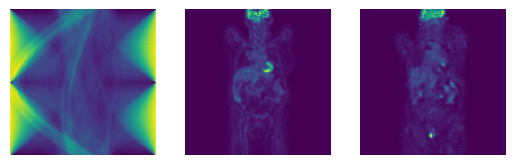

In [ ]:
fig, (ax1, ax2,ax3) = plt.subplots(1, 3)
ax1.set_axis_off()
ax2.set_axis_off()
ax3.set_axis_off()
ax1.imshow(sino_real.cpu().detach().numpy()[0][0].reshape(256,256))
ax2.imshow(pet_real.cpu().detach().numpy()[0][0].reshape(256,256))
ax3.imshow(pet_fake.cpu().detach().numpy()[0][0].reshape(256,256))